# Capstone Project 
## Custom CNN Model Training for Brain Tumor Detection


Vaishnavi already completed preprocessing and created a processed dataset with these folders:

```text
processed_data/
|-- train/
|-- val/
|-- test/
```

This notebook directly uses that processed dataset. It does **not** repeat Vaishnavi's cleaning, resizing, or splitting work.

**Binary labels used here:**

- `Healthy` = 0
- `Tumor` = 1

The model is a custom CNN built using the same Keras `Sequential`, `Conv2D`, `MaxPooling2D`, `Dropout`, `Flatten`, and `Dense` pattern from the class CNN notebook.


## 1. Import Libraries

Run the next cell first. If TensorFlow is missing, install it in the same environment as this notebook.

For Windows users: TensorFlow may not work with very new Python versions such as Python 3.14. A Python 3.10, 3.11, or 3.12 environment is usually safer for TensorFlow/Keras work.


In [2]:
import sys

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install pandas matplotlib seaborn scikit-learn pillow tensorflow

  Using cached pip-26.1.2-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.2-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.0
    Uninstalling pip-24.0:
      Successfully uninstalled pip-24.0
  Using cached matplotlib-3.11.0-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.w

In [3]:
# If a package is missing, uncomment and run this line once:
# %pip install tensorflow pandas numpy matplotlib scikit-learn pillow

import os
import re
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
)

print("TensorFlow version:", tf.__version__)
print("Python version:", os.sys.version)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

if os.sys.version_info >= (3, 13):
    print("WARNING: You are using Python 3.13 or newer. If TensorFlow import/install fails, use Python 3.10, 3.11, or 3.12.")


TensorFlow version: 2.21.0
Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
GPU devices: []


## 2. Set Project Paths

Use the local path where Vaishnavi's processed dataset folder is saved. The folder should contain `train`, `val`, and `test`.


In [4]:
# =========================================
# 2. SET LOCAL DATASET PATH
# =========================================

# IMPORTANT: Change this to your local processed_data folder location.
# Example:
# PROCESSED_DATA_DIR = r"C:\Users\kavya.raghunathan\Desktop\Jupyter_Folder\processed_data"

PROCESSED_DATA_DIR = r"C:\Users\kavya.raghunathan\Desktop\Jupyter_Folder\processed_data"

# Optional: If you only have processed_data.zip, set its path here.
# Leave blank if you already have the extracted processed_data folder.
PROCESSED_ZIP_PATH = r""

# Output folders for Person 2 work
MODEL_DIR = Path("kavya_models")
OUTPUT_DIR = Path("kavya_outputs")
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "kavya_custom_cnn_best.keras"
FINAL_MODEL_PATH = MODEL_DIR / "kavya_custom_cnn_final.keras"

print("Processed dataset folder:", PROCESSED_DATA_DIR)
print("Model output folder:", MODEL_DIR.resolve())
print("Plots/metrics output folder:", OUTPUT_DIR.resolve())


Processed dataset folder: C:\Users\kavya.raghunathan\Desktop\Jupyter_Folder\processed_data
Model output folder: C:\Users\kavya.raghunathan\Desktop\Jupyter_Folder\kavya_models
Plots/metrics output folder: C:\Users\kavya.raghunathan\Desktop\Jupyter_Folder\kavya_outputs


## 3. Locate the Processed Dataset

This cell checks that the processed dataset has the correct split folders.

It also supports either of these structures:

```text
processed_data/train, processed_data/val, processed_data/test
```

or

```text
some_parent_folder/processed_data/train, some_parent_folder/processed_data/val, some_parent_folder/processed_data/test
```


In [5]:
# =========================================
# 3. LOCATE PROCESSED DATASET
# =========================================

SPLITS = ["train", "val", "test"]


def has_split_folders(path: Path) -> bool:
    return all((path / split).is_dir() for split in SPLITS)


def resolve_processed_data_dir(path_value: str, zip_value: str = "") -> Path:
    """Return the folder that contains train/val/test."""
    path = Path(path_value).expanduser()

    if has_split_folders(path):
        return path

    # Optional unzip support
    if zip_value and not path.exists():
        zip_path = Path(zip_value).expanduser()
        if not zip_path.is_file():
            raise FileNotFoundError(f"Zip file not found: {zip_path}")
        path.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(path)
        print(f"Extracted zip file to: {path}")

    if has_split_folders(path):
        return path

    if path.exists():
        # Search one level below the selected folder.
        for child in path.iterdir():
            if child.is_dir() and has_split_folders(child):
                return child

    raise FileNotFoundError(
        "Could not find train/val/test folders. Please update PROCESSED_DATA_DIR "
        "so it points to the processed_data folder created by Person 1."
    )


DATA_DIR = resolve_processed_data_dir(PROCESSED_DATA_DIR, PROCESSED_ZIP_PATH)
train_dir = DATA_DIR / "train"
val_dir = DATA_DIR / "val"
test_dir = DATA_DIR / "test"

print("Using processed dataset at:", DATA_DIR.resolve())
print("Train folder:", train_dir)
print("Validation folder:", val_dir)
print("Test folder:", test_dir)

for split in SPLITS:
    split_path = DATA_DIR / split
    print(f"{split} folder items:", len(list(split_path.iterdir())))


Using processed dataset at: C:\Users\kavya.raghunathan\Desktop\Jupyter_Folder\processed_data
Train folder: C:\Users\kavya.raghunathan\Desktop\Jupyter_Folder\processed_data\train
Validation folder: C:\Users\kavya.raghunathan\Desktop\Jupyter_Folder\processed_data\val
Test folder: C:\Users\kavya.raghunathan\Desktop\Jupyter_Folder\processed_data\test
train folder items: 3159
val folder items: 677
test folder items: 678


## 4. Create Labels from Vaishnavi's Processed Files

Vaishnavi's processed folders may contain images directly inside `train`, `val`, and `test` instead of class subfolders.

So this notebook infers labels from file names/folder names:

- File or folder containing `Not Cancer`, `Healthy`, `Normal`, or `No Tumor` -> `Healthy`
- File or folder containing `Cancer`, `Tumor`, or `Brain Tumor` -> `Tumor`

`Not Cancer` is checked first because it also contains the word `Cancer`.


In [6]:
# =========================================
# 4. READ IMAGE PATHS AND CREATE LABELS
# =========================================

SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
CLASS_NAMES = ["Healthy", "Tumor"]
CLASS_TO_INDEX = {"Healthy": 0, "Tumor": 1}


def normalize_text(text: str) -> str:
    text = text.lower().replace("_", " ").replace("-", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def infer_label_from_path(path: Path) -> str:
    # Use both parent folders and filename so the code works for flat folders and class-wise folders.
    text = normalize_text(" ".join(path.parts[-4:]))

    # Healthy terms must be checked before Tumor terms.
    healthy_terms = ["not cancer", "no cancer", "healthy", "normal", "no tumor", "not tumor"]
    tumor_terms = ["brain tumor", "tumor", "cancer"]

    if any(term in text for term in healthy_terms):
        return "Healthy"
    if any(term in text for term in tumor_terms):
        return "Tumor"

    raise ValueError(f"Could not infer label for file: {path}")


def build_split_dataframe(split: str) -> pd.DataFrame:
    split_path = DATA_DIR / split
    image_paths = [
        p for p in split_path.rglob("*")
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
    ]

    rows = []
    unknown_files = []

    for path in sorted(image_paths):
        try:
            label = infer_label_from_path(path)
            rows.append({
                "filepath": str(path),
                "filename": path.name,
                "split": split,
                "label": label,
                "target": CLASS_TO_INDEX[label],
            })
        except ValueError:
            unknown_files.append(str(path))

    if unknown_files:
        print("Files with unknown labels. Rename these files/folders or update infer_label_from_path():")
        for item in unknown_files[:10]:
            print(item)
        raise ValueError(f"Could not infer labels for {len(unknown_files)} files.")

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f"No image files found in {split_path}")
    return df


train_df = build_split_dataframe("train")
val_df = build_split_dataframe("val")
test_df = build_split_dataframe("test")

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("Total images:", len(all_df))
print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

summary = pd.crosstab(all_df["split"], all_df["label"])
display(summary)

# Save file lists for reproducibility.
train_df.to_csv(OUTPUT_DIR / "kavya_train_files.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "kavya_val_files.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "kavya_test_files.csv", index=False)


Total images: 4514
Train images: 3159
Validation images: 677
Test images: 678


label,Healthy,Tumor
split,,
test,281,397
train,1489,1670
val,317,360


## 5. Quick Image Check

This verifies that the processed images can be opened. Since Vaishnavi already resized and converted the images, this is only a safety check before model training.


In [7]:
# =========================================
# 5. VERIFY IMAGE FILES
# =========================================

def find_unreadable_images(df: pd.DataFrame, max_report: int = 10):
    bad_files = []
    for path in df["filepath"]:
        try:
            with Image.open(path) as img:
                img.verify()
        except Exception:
            bad_files.append(path)
            if len(bad_files) <= max_report:
                print("Unreadable image:", path)
    return bad_files

bad_files = find_unreadable_images(all_df)

if bad_files:
    print(f"Found {len(bad_files)} unreadable images. They will be removed from the dataframes.")
    train_df = train_df[~train_df["filepath"].isin(bad_files)].reset_index(drop=True)
    val_df = val_df[~val_df["filepath"].isin(bad_files)].reset_index(drop=True)
    test_df = test_df[~test_df["filepath"].isin(bad_files)].reset_index(drop=True)
else:
    print("All checked images are readable.")


All checked images are readable.


## 6. Visualize Sample Images

show a few processed brain scan images with their labels before training.


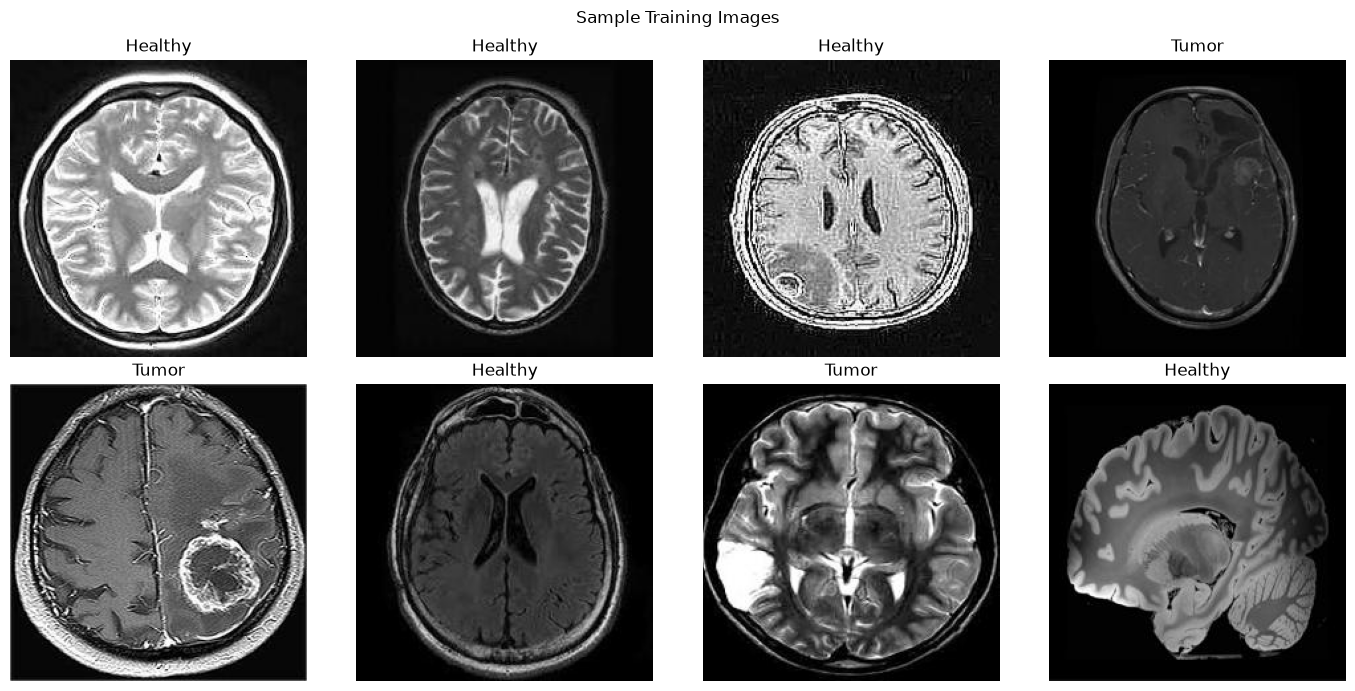

In [8]:
# =========================================
# 6. SHOW SAMPLE IMAGES
# =========================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


def show_samples(df: pd.DataFrame, title: str, n: int = 8):
    sample_df = df.sample(n=min(n, len(df)), random_state=SEED).reset_index(drop=True)
    plt.figure(figsize=(14, 7))
    for i, row in sample_df.iterrows():
        img = Image.open(row["filepath"])
        plt.subplot(2, 4, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(row["label"])
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(train_df, "Sample Training Images")


## 7. Set Model Parameters

The image size is kept at `224 x 224` to match Vaishnavi's preprocessing and the project plan.


In [9]:
# =========================================
# 7. SET MODEL PARAMETERS
# =========================================

BATCH_SIZE = 32
IMG_SHAPE = 224
EPOCHS = 20

print("Batch size:", BATCH_SIZE)
print("Image shape:", IMG_SHAPE, "x", IMG_SHAPE)
print("Epochs:", EPOCHS)


Batch size: 32
Image shape: 224 x 224
Epochs: 20


## 8. Data Augmentation and Data Generators

Only the training data is augmented. Validation and test data are only rescaled.

The augmentation is intentionally simple because medical images can be sensitive. Horizontal flip is kept off by default.


In [10]:
# =========================================
# 8. DATA AUGMENTATION AND GENERATORS
# =========================================

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    brightness_range=(0.85, 1.15),
    horizontal_flip=False,
    fill_mode="nearest",
)

validation_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

training_set = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    classes=CLASS_NAMES,
    target_size=(IMG_SHAPE, IMG_SHAPE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True,
    seed=SEED,
)

validation_set = validation_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    classes=CLASS_NAMES,
    target_size=(IMG_SHAPE, IMG_SHAPE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

test_set = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    classes=CLASS_NAMES,
    target_size=(IMG_SHAPE, IMG_SHAPE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False,
)

print("Class indices:", training_set.class_indices)
print("Training batches:", len(training_set))
print("Validation batches:", len(validation_set))
print("Test batches:", len(test_set))


Found 3159 validated image filenames belonging to 2 classes.
Found 677 validated image filenames belonging to 2 classes.
Found 678 validated image filenames belonging to 2 classes.
Class indices: {'Healthy': 0, 'Tumor': 1}
Training batches: 99
Validation batches: 22
Test batches: 22


## 9. Class Weights

The dataset is slightly imbalanced, so class weights are calculated from the training split. This helps the custom CNN pay attention to both classes.


In [11]:
# =========================================
# 9. CLASS WEIGHTS
# =========================================

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["target"].values,
)

class_weight = {
    0: class_weights_array[0],
    1: class_weights_array[1],
}

print("Class mapping:", CLASS_TO_INDEX)
print("Class weights:", class_weight)


Class mapping: {'Healthy': 0, 'Tumor': 1}
Class weights: {0: np.float64(1.0607790463398254), 1: np.float64(0.9458083832335329)}


## 10. Build the Custom CNN Model

This is Person 2's custom CNN baseline model.

The model follows the class notebook pattern:

1. Initialize `Sequential()`
2. Add convolution layers using `Conv2D`
3. Add pooling layers using `MaxPooling2D`
4. Add `Dropout`
5. Add `Flatten`
6. Add fully connected `Dense` layers
7. Compile the model


In [12]:
# =========================================
# 10. MODEL CREATION - CUSTOM CNN
# =========================================

# Initialising the CNN
classifier = Sequential(name="person2_custom_cnn")

# Step 1 - Convolution + Pooling
classifier.add(Conv2D(32, (3, 3), input_shape=(IMG_SHAPE, IMG_SHAPE, 3), activation="relu", name="custom_conv_1"))
classifier.add(MaxPooling2D(pool_size=(2, 2), name="custom_pool_1"))

# Step 2 - More convolution + pooling layers
classifier.add(Conv2D(64, (3, 3), activation="relu", name="custom_conv_2"))
classifier.add(MaxPooling2D(pool_size=(2, 2), name="custom_pool_2"))

classifier.add(Conv2D(128, (3, 3), activation="relu", name="custom_conv_3"))
classifier.add(MaxPooling2D(pool_size=(2, 2), name="custom_pool_3"))

classifier.add(Conv2D(128, (3, 3), activation="relu", name="custom_conv_4"))
classifier.add(MaxPooling2D(pool_size=(2, 2), name="custom_pool_4"))

# Last convolution layer for Grad-CAM handoff
classifier.add(Conv2D(256, (3, 3), activation="relu", name="custom_conv_5"))
classifier.add(MaxPooling2D(pool_size=(2, 2), name="custom_pool_5"))

# Step 3 - Dropout
classifier.add(Dropout(0.5, name="dropout_1"))

# Step 4 - Flattening
classifier.add(Flatten(name="flatten"))

# Step 5 - Full connection
classifier.add(Dense(units=256, activation="relu", name="dense_1"))
classifier.add(Dropout(0.5, name="dropout_2"))

# Binary output: 0 = Healthy, 1 = Tumor
classifier.add(Dense(units=1, activation="sigmoid", name="output"))

classifier.summary()


C:\Users\kavya.raghunathan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "person2_custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ custom_conv_1 (Conv2D)               │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ custom_pool_1 (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ custom_conv_2 (Conv2D)               │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ custom_pool_2 (MaxPooling2D)         │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ custom_conv_3 (Conv2D)               │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ custom_pool_3 (MaxPooling2D)         │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ custom_conv_4 (Conv2D)               │ (None, 24, 24, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ custom_pool_4 (MaxPooling2D)         │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ custom_conv_5 (Conv2D)               │ (None, 10, 10, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ custom_pool_5 (MaxPooling2D)         │ (None, 5, 5, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 5, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │       1,638,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,174,913 (8.30 MB)

 Trainable params: 2,174,913 (8.30 MB)

 Non-trainable params: 0 (0.00 B)

## 11. Compile the Model

Metrics are selected for medical-image classification reporting:

- Accuracy
- Precision
- Recall / sensitivity
- AUC

Tumor recall is especially important because missing a tumor case is serious.


In [13]:
# =========================================
# 11. COMPILE THE CNN
# =========================================

classifier.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc"),
    ],
)

print("Model compiled successfully.")


Model compiled successfully.


## 12. Train the Custom CNN

`ModelCheckpoint` saves the best validation model automatically.

`EarlyStopping` helps stop training if validation performance stops improving.


In [14]:
# =========================================
# 12. TRAIN THE MODEL
# =========================================

callbacks = [
    ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_recall",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_recall",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = classifier.fit(
    training_set,
    epochs=EPOCHS,
    validation_data=validation_set,
    class_weight=class_weight,
    callbacks=callbacks,
)

classifier.save(FINAL_MODEL_PATH)
print("Saved final model to:", FINAL_MODEL_PATH)
print("Saved best validation model to:", BEST_MODEL_PATH)


Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.5442 - auc: 0.5584 - loss: 0.6823 - precision: 0.5662 - recall: 0.6291
Epoch 1: val_recall improved from None to 0.91944, saving model to kavya_models\kavya_custom_cnn_best.keras

Epoch 1: finished saving model to kavya_models\kavya_custom_cnn_best.keras
99/99 ━━━━━━━━━━━━━━━━━━━━ 88s 842ms/step - accuracy: 0.5878 - auc: 0.6159 - loss: 0.6604 - precision: 0.5955 - recall: 0.6868 - val_accuracy: 0.7282 - val_auc: 0.7421 - val_loss: 0.5626 - val_precision: 0.6811 - val_recall: 0.9194 - learning_rate: 0.0010
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - accuracy: 0.6760 - auc: 0.7090 - loss: 0.6132 - precision: 0.6703 - recall: 0.8001
Epoch 2: val_recall did not improve from 0.91944
99/99 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.6888 - auc: 0.7366 - loss: 0.5965 - precision: 0.6779 - recall: 0.7838 - val_accuracy: 0.6809 - val_auc: 0.7967 - val_loss: 0.5632 - val_precision: 0.7236 - val_recall: 0.6472 - learn

## 13. Training Result Visualization

These plots are useful for the final report and presentation.


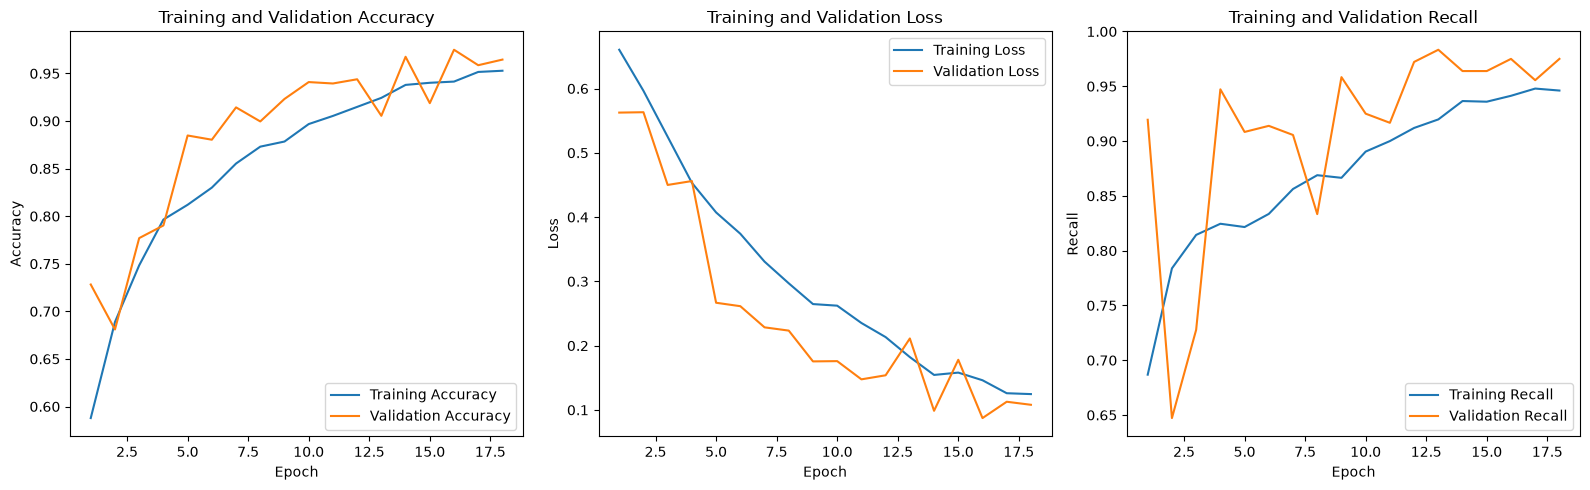

In [15]:
# =========================================
# 13. TRAINING RESULT VISUALIZATION
# =========================================

history_df = pd.DataFrame(history.history)
history_df.to_csv(OUTPUT_DIR / "kavya_custom_cnn_training_history.csv", index=False)

def plot_training_history(history_obj):
    acc = history_obj.history.get("accuracy", [])
    val_acc = history_obj.history.get("val_accuracy", [])
    loss = history_obj.history.get("loss", [])
    val_loss = history_obj.history.get("val_loss", [])
    recall = history_obj.history.get("recall", [])
    val_recall = history_obj.history.get("val_recall", [])

    epochs_range = range(1, len(loss) + 1)

    plt.figure(figsize=(16, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.legend(loc="lower right")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.legend(loc="upper right")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, recall, label="Training Recall")
    plt.plot(epochs_range, val_recall, label="Validation Recall")
    plt.legend(loc="lower right")
    plt.title("Training and Validation Recall")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "person2_custom_cnn_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_training_history(history)


## 14. Evaluate the Best Custom CNN on the Test Set

The best saved model is loaded before testing.


In [16]:
# =========================================
# 14. TEST SET EVALUATION
# =========================================

best_classifier = tf.keras.models.load_model(BEST_MODEL_PATH)

print("Evaluating best custom CNN model on test set...")
test_results = best_classifier.evaluate(test_set, verbose=1)

for metric_name, metric_value in zip(best_classifier.metrics_names, test_results):
    print(f"{metric_name}: {metric_value:.4f}")


Evaluating best custom CNN model on test set...
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 579ms/step - accuracy: 0.9100 - auc: 0.9759 - loss: 0.2502 - precision: 0.8801 - recall: 0.9798
loss: 0.2502
compile_metrics: 0.9100


## 15. Classification Report and Confusion Matrix

The positive class is `Tumor`. A predicted probability greater than or equal to `0.50` is treated as `Tumor`.


22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step
Class indices: {'Healthy': 0, 'Tumor': 1}
Threshold used: 0.5

Classification Report:
              precision    recall  f1-score   support

     Healthy     0.9661    0.8114    0.8820       281
       Tumor     0.8801    0.9798    0.9273       397

    accuracy                         0.9100       678
   macro avg     0.9231    0.8956    0.9047       678
weighted avg     0.9157    0.9100    0.9085       678



,precision,recall,f1-score,support
Healthy,0.966102,0.811388,0.882012,281.000000
Tumor,0.880090,0.979849,0.927294,397.000000
accuracy,0.910029,0.910029,0.910029,0.910029
macro avg,0.923096,0.895618,0.904653,678.000000
weighted avg,0.915738,0.910029,0.908527,678.000000


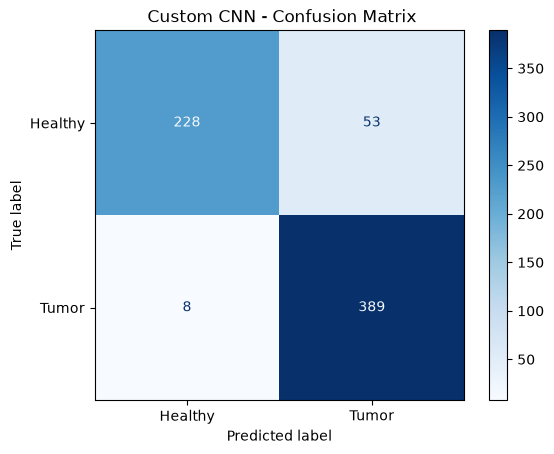

,model,threshold,test_accuracy,tumor_precision,tumor_recall_sensitivity,tumor_f1_score,roc_auc
0,Custom CNN,0.5,0.910029,0.88009,0.979849,0.927294,0.977016


Tumor Recall / Sensitivity: 0.9798
ROC-AUC: 0.9770


In [18]:
# =========================================
# 15. CLASSIFICATION REPORT AND CONFUSION MATRIX
# =========================================

DEFAULT_THRESHOLD = 0.50

test_set.reset()
y_true = test_set.classes

y_pred_prob = best_classifier.predict(test_set, verbose=1).ravel()
y_pred = (y_pred_prob >= DEFAULT_THRESHOLD).astype(int)

print("Class indices:", test_set.class_indices)
print("Threshold used:", DEFAULT_THRESHOLD)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(OUTPUT_DIR / "person2_custom_cnn_classification_report.csv")
display(report_df)

cm = confusion_matrix(y_true, y_pred)
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
cmd.plot(cmap="Blues", values_format="d")
plt.title(" Custom CNN - Confusion Matrix")
plt.savefig(OUTPUT_DIR / "kavya_custom_cnn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

try:
    test_auc = roc_auc_score(y_true, y_pred_prob)
    tumor_recall = report_dict["Tumor"]["recall"]
    tumor_precision = report_dict["Tumor"]["precision"]
    tumor_f1 = report_dict["Tumor"]["f1-score"]

    metrics_summary = pd.DataFrame([
        {
            "model": "Custom CNN",
            "threshold": DEFAULT_THRESHOLD,
            "test_accuracy": report_dict["accuracy"],
            "tumor_precision": tumor_precision,
            "tumor_recall_sensitivity": tumor_recall,
            "tumor_f1_score": tumor_f1,
            "roc_auc": test_auc,
        }
    ])
    metrics_summary.to_csv(OUTPUT_DIR / "kavya_custom_cnn_metrics_summary.csv", index=False)
    display(metrics_summary)

    print(f"Tumor Recall / Sensitivity: {tumor_recall:.4f}")
    print(f"ROC-AUC: {test_auc:.4f}")
except Exception as e:
    print("Could not calculate ROC-AUC or summary metrics:", e)


## 16. ROC Curve

ROC-AUC is an extra metric that helps compare models later.


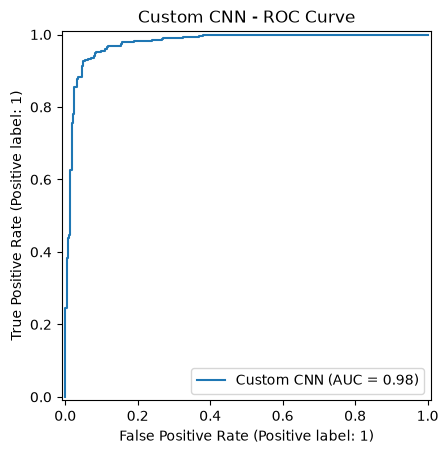

In [19]:
# =========================================
# 16. ROC CURVE
# =========================================

RocCurveDisplay.from_predictions(y_true, y_pred_prob, name="Custom CNN")
plt.title("Custom CNN - ROC Curve")
plt.savefig(OUTPUT_DIR / "kavya_custom_cnn_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## 17. Optional Threshold Check on Validation Set

For medical-image classification, tumor recall/sensitivity is important.

This cell checks different thresholds using the validation set. The final threshold decision can be made during the full model comparison stage.


In [20]:
# =========================================
# 17. OPTIONAL THRESHOLD CHECK USING VALIDATION SET
# =========================================

validation_set.reset()
val_true = validation_set.classes
val_pred_prob = best_classifier.predict(validation_set, verbose=1).ravel()

threshold_rows = []
for threshold in np.arange(0.10, 0.91, 0.05):
    val_pred = (val_pred_prob >= threshold).astype(int)
    report = classification_report(val_true, val_pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
    threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "accuracy": report["accuracy"],
        "tumor_precision": report["Tumor"]["precision"],
        "tumor_recall": report["Tumor"]["recall"],
        "tumor_f1": report["Tumor"]["f1-score"],
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(OUTPUT_DIR / "kavya_custom_cnn_threshold_check.csv", index=False)
display(threshold_df.sort_values(by=["tumor_f1", "tumor_recall"], ascending=False).head(10))


22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step


,threshold,accuracy,tumor_precision,tumor_recall,tumor_f1
15,0.85,0.951256,0.955432,0.952778,0.954103
16,0.90,0.949778,0.963068,0.941667,0.952247
14,0.80,0.946824,0.940217,0.961111,0.950549
13,0.75,0.940916,0.925532,0.966667,0.945652
12,0.70,0.935007,0.913613,0.969444,0.940701
11,0.65,0.929099,0.902062,0.972222,0.935829
10,0.60,0.924668,0.893130,0.975000,0.932271
9,0.55,0.918759,0.880299,0.980556,0.927727
8,0.50,0.905465,0.859223,0.983333,0.917098
7,0.45,0.898080,0.847255,0.986111,0.911425


## 18. Test a Single Image Prediction

Use this function for quick demo testing with any image path.


Example image: C:\Users\kavya.raghunathan\Desktop\Jupyter_Folder\processed_data\test\Cancer (1003).jpg


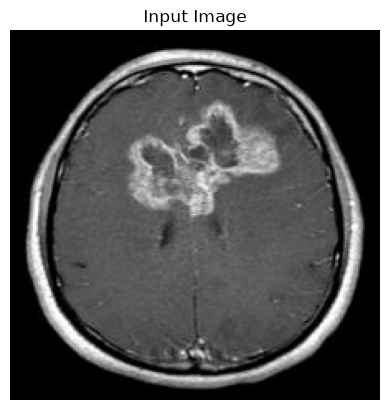

Tumor probability: 1.0
Predicted label: Tumor
Confidence: 100.0 %


('Tumor', 0.9999998807907104, 0.9999998807907104)

In [21]:
# =========================================
# 18. SINGLE IMAGE PREDICTION FUNCTION
# =========================================

INDEX_TO_CLASS = {0: "Healthy", 1: "Tumor"}


def predict_image(model, img_path: str, target_shape=(IMG_SHAPE, IMG_SHAPE), threshold: float = DEFAULT_THRESHOLD):
    original_image = Image.open(img_path).convert("RGB")
    plt.imshow(original_image, cmap="gray")
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img = load_img(img_path, target_size=target_shape)
    img_array = img_to_array(img) / 255.0
    input_array = np.expand_dims(img_array, axis=0)

    tumor_probability = float(model.predict(input_array, verbose=0)[0][0])
    predicted_index = int(tumor_probability >= threshold)
    predicted_label = INDEX_TO_CLASS[predicted_index]
    confidence = tumor_probability if predicted_label == "Tumor" else 1.0 - tumor_probability

    print("Tumor probability:", round(tumor_probability, 4))
    print("Predicted label:", predicted_label)
    print("Confidence:", round(confidence * 100, 2), "%")

    return predicted_label, confidence, tumor_probability


# Example usage with one test image:
example_path = test_df.iloc[0]["filepath"]
print("Example image:", example_path)
predict_image(best_classifier, example_path)


## 19. Show Sample Test Predictions

This creates a presentation-friendly grid of sample predictions.


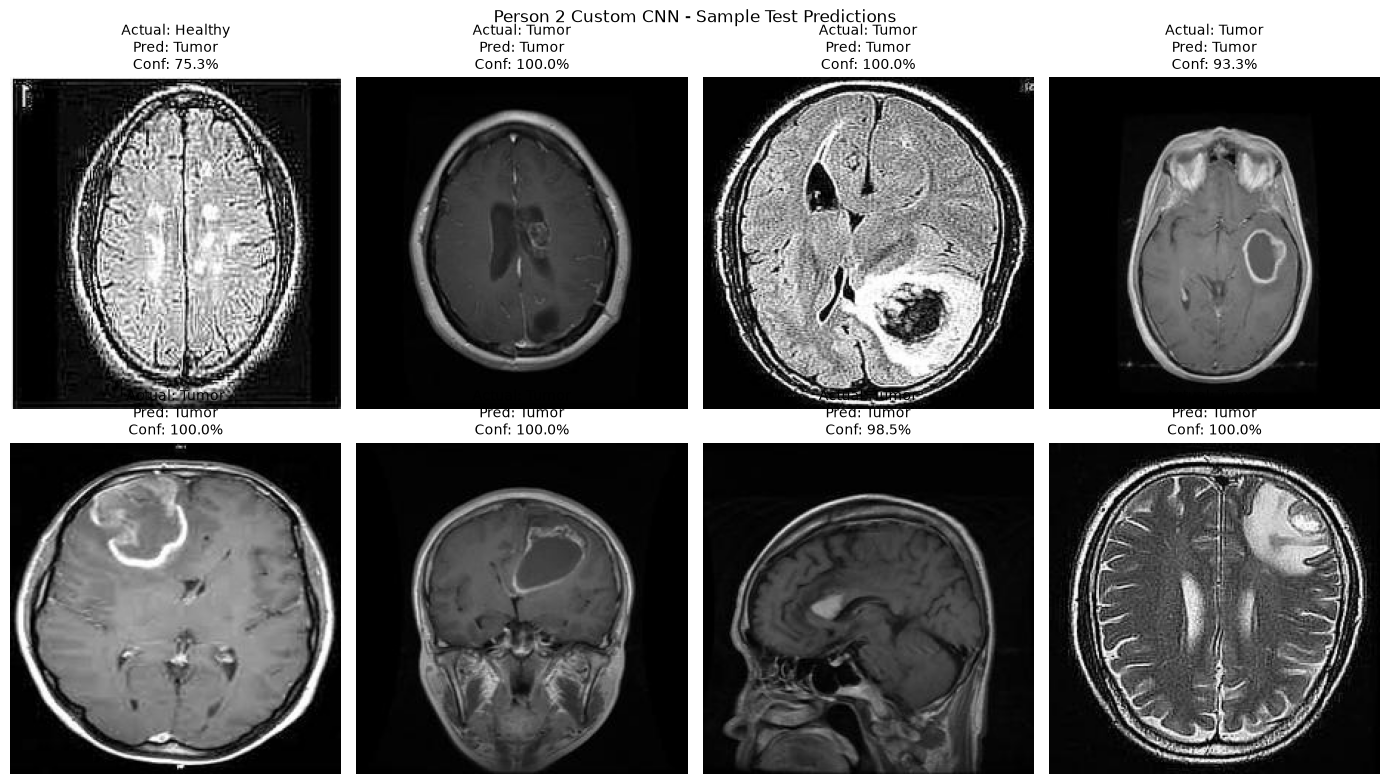

In [22]:
# =========================================
# 19. SAMPLE TEST PREDICTIONS
# =========================================

sample_df = test_df.sample(n=min(8, len(test_df)), random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(14, 8))
for i, row in sample_df.iterrows():
    img = load_img(row["filepath"], target_size=(IMG_SHAPE, IMG_SHAPE))
    img_array = img_to_array(img) / 255.0
    input_array = np.expand_dims(img_array, axis=0)

    tumor_probability = float(best_classifier.predict(input_array, verbose=0)[0][0])
    pred_label = "Tumor" if tumor_probability >= DEFAULT_THRESHOLD else "Healthy"
    confidence = tumor_probability if pred_label == "Tumor" else 1.0 - tumor_probability

    plt.subplot(2, 4, i + 1)
    plt.imshow(Image.open(row["filepath"]).convert("RGB"), cmap="gray")
    plt.axis("off")
    plt.title(
        f"Actual: {row['label']}\nPred: {pred_label}\nConf: {confidence * 100:.1f}%",
        fontsize=10,
    )

plt.suptitle("Person 2 Custom CNN - Sample Test Predictions")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "person2_custom_cnn_sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()


## 20. Person 2 Handoff Notes

Use these outputs for the next project stages:

```text
kavya_models/kavya_custom_cnn_best.keras
kavya_models/kavya_custom_cnn_final.keras

kavya_outputs/kavya_custom_cnn_training_curves.png
kavya_outputs/kavya_custom_cnn_confusion_matrix.png
kavya_outputs/kavya_custom_cnn_roc_curve.png
kavya_outputs/kavya_custom_cnn_metrics_summary.csv
```

For Grad-CAM, Person 4 can use this last convolution layer name:

```python
last_conv_layer_name = "custom_conv_5"
```

For model comparison, report at least:

- Test accuracy
- Tumor precision
- Tumor recall/sensitivity
- Tumor F1-score
- ROC-AUC
- Confusion matrix


In [23]:
# =========================================
# 20. FINAL HANDOFF VARIABLES
# =========================================

last_conv_layer_name = "custom_conv_5"
positive_class_name = "Tumor"
healthy_class_name = "Healthy"

print("Best custom CNN model:", BEST_MODEL_PATH)
print("Final custom CNN model:", FINAL_MODEL_PATH)
print("Last convolution layer for Grad-CAM:", last_conv_layer_name)
print("Class names:", CLASS_NAMES)
print("Kavya's custom CNN notebook completed.")


Best custom CNN model: kavya_models\kavya_custom_cnn_best.keras
Final custom CNN model: kavya_models\kavya_custom_cnn_final.keras
Last convolution layer for Grad-CAM: custom_conv_5
Class names: ['Healthy', 'Tumor']
Kavya's custom CNN notebook completed.
